# Day 01 — Sales Analysis

## 1. Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries importées avec succès !")

✅ Libraries importées avec succès !


## 2. Load Data

In [5]:
# Charger le dataset
df = pd.read_csv('data/Sample - Superstore.csv', encoding='latin-1')

# Premier coup d'oeil
print("📐 Dimensions du dataset :")
print(f"   {df.shape[0]} lignes  x  {df.shape[1]} colonnes")

print("\n📋 Noms des colonnes :")
print(df.columns.tolist())

print("\n👀 Les 5 premières lignes :")
df.head()

📐 Dimensions du dataset :
   9994 lignes  x  21 colonnes

📋 Noms des colonnes :
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

👀 Les 5 premières lignes :


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Data Cleaning

In [6]:
print("📊 Infos générales :")
df.info()

📊 Infos générales :
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18 

In [7]:
print("📈 Statistiques descriptives :")
df.describe()

📈 Statistiques descriptives :


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
print("❓ Valeurs manquantes par colonne :")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\n✅ Total de valeurs manquantes : {df.isnull().sum().sum()}")

❓ Valeurs manquantes par colonne :
Series([], dtype: int64)

✅ Total de valeurs manquantes : 0


In [9]:
doublons = df.duplicated().sum()
print(f"🔁 Nombre de lignes dupliquées : {doublons}")

🔁 Nombre de lignes dupliquées : 0


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')

print("✅ Dates converties !")
print(f"Années disponibles : {sorted(df['Year'].unique())}")
print(f"Nouvelles colonnes : {['Year', 'Month', 'Month Name']}")
print(f"\nNouvelle taille du dataset : {df.shape}")

✅ Dates converties !
Années disponibles : [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Nouvelles colonnes : ['Year', 'Month', 'Month Name']

Nouvelle taille du dataset : (9994, 24)


## 4. Exploratory Data Analysis

QUESTION 1 : Ventes par Catégorie
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


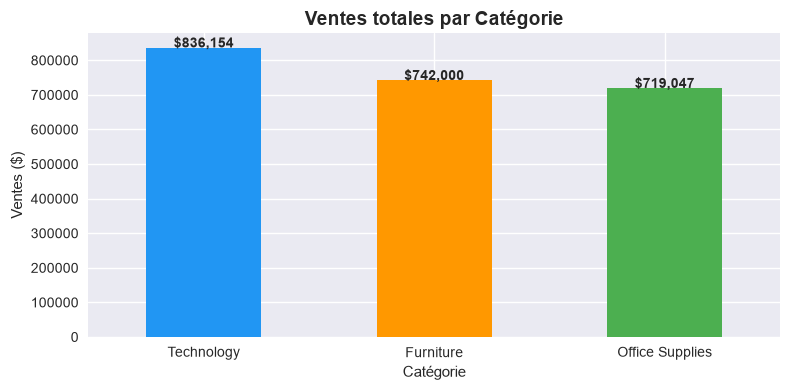

✅ Graphique sauvegardé dans images/


In [11]:
print("=" * 50)
print("QUESTION 1 : Ventes par Catégorie")
print("=" * 50)

ventes_categorie = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(ventes_categorie)

# Graphique
fig, ax = plt.subplots(figsize=(8, 4))
ventes_categorie.plot(kind='bar', ax=ax, color=['#2196F3', '#FF9800', '#4CAF50'])
ax.set_title('Ventes totales par Catégorie', fontsize=14, fontweight='bold')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Ventes ($)')
ax.tick_params(axis='x', rotation=0)

# Ajouter les valeurs sur chaque barre
for i, v in enumerate(ventes_categorie):
    ax.text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/q1_ventes_categorie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé dans images/")

In [14]:
# Correction : remplacer les noms français par anglais via dictionnaire
mois_en = {1:'January', 2:'February', 3:'March', 4:'April',
           5:'May', 6:'June', 7:'July', 8:'August',
           9:'September', 10:'October', 11:'November', 12:'December'}

df['Month Name'] = df['Month'].map(mois_en)

print("✅ Correction appliquée !")
print("Vérification :", df['Month Name'].unique())

✅ Correction appliquée !
Vérification : <StringArray>
[ 'November',      'June',   'October',     'April',  'December',       'May',
    'August',      'July', 'September',   'January',     'March',  'February']
Length: 12, dtype: str


QUESTION 2 : Ventes par Mois
Month Name
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64


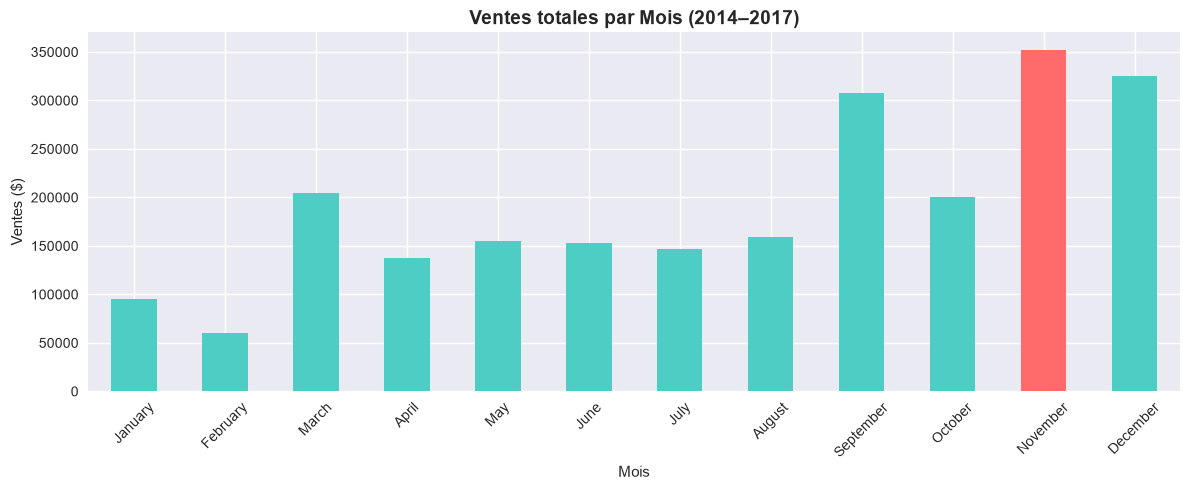

✅ Graphique sauvegardé !


In [15]:
print("=" * 50)
print("QUESTION 2 : Ventes par Mois")
print("=" * 50)

# Ordre des mois (janvier → décembre)
ordre_mois = ['January','February','March','April','May','June',
              'July','August','September','October','November','December']

ventes_mois = df.groupby('Month Name')['Sales'].sum()
ventes_mois = ventes_mois.reindex(ordre_mois)  # remet les mois dans l'ordre

print(ventes_mois)

# Graphique
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#FF6B6B' if v == ventes_mois.max() else '#4ECDC4' for v in ventes_mois]
ventes_mois.plot(kind='bar', ax=ax, color=colors)

ax.set_title('Ventes totales par Mois (2014–2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Ventes ($)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/q2_ventes_mois.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

QUESTION 3 : Profit par Catégorie
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


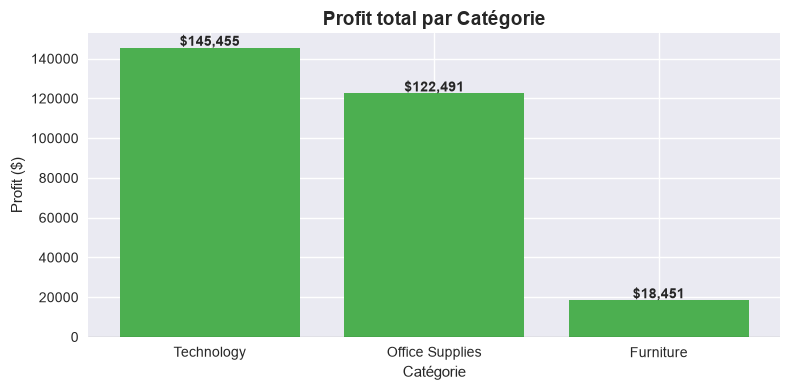

✅ Graphique sauvegardé !


In [16]:
print("=" * 50)
print("QUESTION 3 : Profit par Catégorie")
print("=" * 50)

profit_categorie = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(profit_categorie)

# Graphique avec couleurs conditionnelles (vert = profit, rouge = perte)
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4CAF50' if v > 0 else '#F44336' for v in profit_categorie]
bars = ax.bar(profit_categorie.index, profit_categorie.values, color=colors)

ax.set_title('Profit total par Catégorie', fontsize=14, fontweight='bold')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Profit ($)')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)  # ligne zéro

# Valeurs sur les barres
for bar, val in zip(bars, profit_categorie.values):
    ypos = val + 1000 if val > 0 else val - 5000
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'${val:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('images/q3_profit_categorie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

QUESTION 4 : Top 10 États par Ventes
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


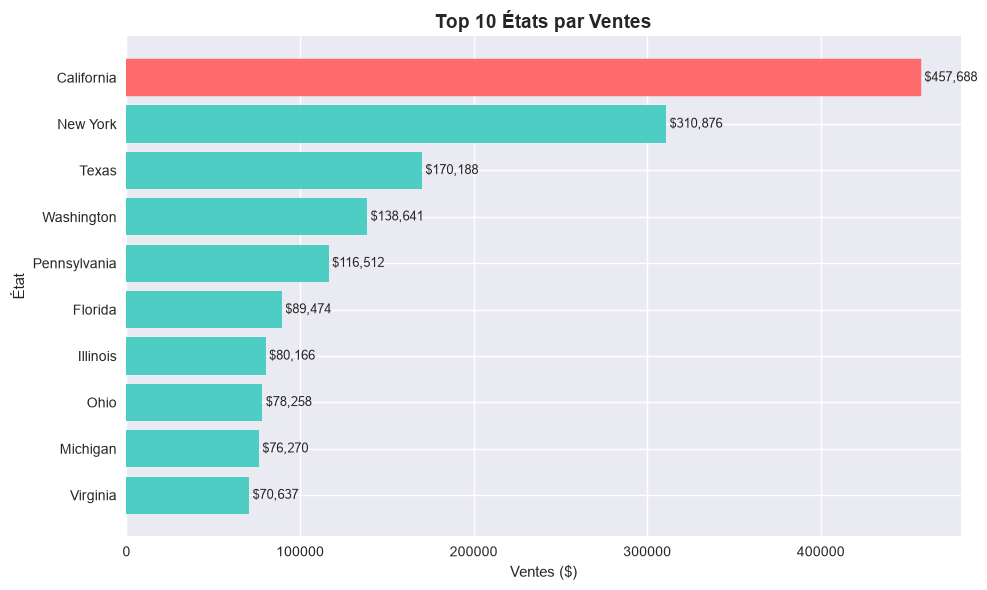

✅ Graphique sauvegardé !


In [18]:
print("=" * 50)
print("QUESTION 4 : Top 10 États par Ventes")
print("=" * 50)

top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_states)

# Correction : trier ascending=True pour barh (plus grand en haut)
top_states_plot = top_states.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_states_plot.index, top_states_plot.values, color='#4ECDC4')

# Colorier le plus grand en rouge
bars[-1].set_color('#FF6B6B')

ax.set_title('Top 10 États par Ventes', fontsize=14, fontweight='bold')
ax.set_xlabel('Ventes ($)')
ax.set_ylabel('État')

# Valeurs à droite de chaque barre
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2000, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/q4_top_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

QUESTION 5 : Produits vendus à perte
Sous-catégories vendues à PERTE :
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64

Total des pertes : $-22,387


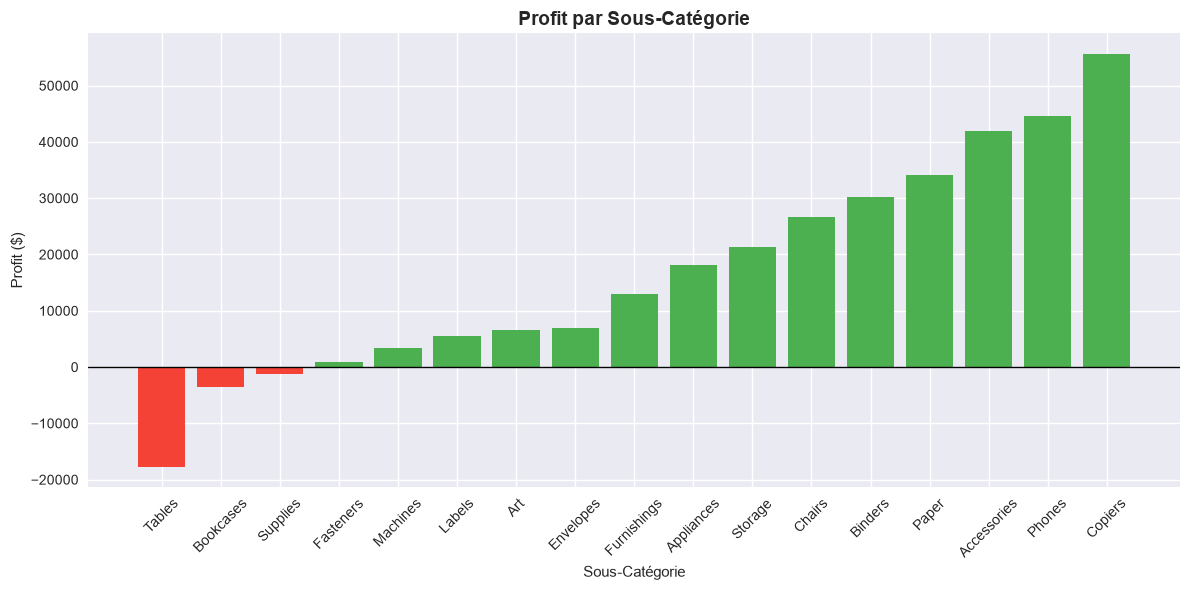


✅ 3 sous-catégorie(s) vendue(s) à perte sur 17 au total


In [19]:
print("=" * 50)
print("QUESTION 5 : Produits vendus à perte")
print("=" * 50)

# Filtrer les sous-catégories avec profit négatif
profit_subcategory = df.groupby('Sub-Category')['Profit'].sum().sort_values()
pertes = profit_subcategory[profit_subcategory < 0]

print(f"Sous-catégories vendues à PERTE :")
print(pertes)
print(f"\nTotal des pertes : ${pertes.sum():,.0f}")

# Graphique : toutes les sous-catégories, rouge si perte
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#F44336' if v < 0 else '#4CAF50' for v in profit_subcategory]
bars = ax.bar(profit_subcategory.index, profit_subcategory.values, color=colors)

ax.set_title('Profit par Sous-Catégorie', fontsize=14, fontweight='bold')
ax.set_xlabel('Sous-Catégorie')
ax.set_ylabel('Profit ($)')
ax.axhline(y=0, color='black', linewidth=1)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/q5_profit_subcategory.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ {len(pertes)} sous-catégorie(s) vendue(s) à perte sur {len(profit_subcategory)} au total")

## 6. Insights & Conclusions

In [20]:
print("=" * 60)
print("📊 RÉSUMÉ DES 5 INSIGHTS — Day 01 Sales Analysis")
print("=" * 60)

print("""
🔍 INSIGHT 1 — Ventes par Catégorie
   → Technology domine avec $836,154 de ventes
   → Les 3 catégories sont proches — pas de dominance écrasante

🔍 INSIGHT 2 — Saisonnalité des ventes
   → November est le mois record ($352,461)
   → Pattern clair : ventes explosent en Q4 (Sep-Oct-Nov-Dec)
   → February est le mois le plus faible ($62,000)
   → Recommandation : renforcer les stocks et équipes en Q4

🔍 INSIGHT 3 — Profit vs Ventes (attention !)
   → Furniture vend $742,000 MAIS génère seulement $18,451 de profit
   → Technology = meilleur ratio ventes/profit ($145,455)
   → Recommandation : revoir les marges sur Furniture

🔍 INSIGHT 4 — Géographie des ventes
   → California (#1) génère $457,688 — presque 50% de plus que New York
   → Top 3 : California, New York, Texas
   → Opportunité : les états du centre sont sous-exploités

🔍 INSIGHT 5 — Produits vendus à perte
   → 3 sous-catégories sur 17 sont déficitaires
   → Tables perd $17,725 — pire produit du catalogue
   → Recommandation : augmenter les prix ou arrêter la vente de Tables
""")

print("=" * 60)
print("✅ Day 01 terminé ! Projet sauvegardé dans images/")
print("=" * 60)

📊 RÉSUMÉ DES 5 INSIGHTS — Day 01 Sales Analysis

🔍 INSIGHT 1 — Ventes par Catégorie
   → Technology domine avec $836,154 de ventes
   → Les 3 catégories sont proches — pas de dominance écrasante

🔍 INSIGHT 2 — Saisonnalité des ventes
   → November est le mois record ($352,461)
   → Pattern clair : ventes explosent en Q4 (Sep-Oct-Nov-Dec)
   → February est le mois le plus faible ($62,000)
   → Recommandation : renforcer les stocks et équipes en Q4

🔍 INSIGHT 3 — Profit vs Ventes (attention !)
   → Furniture vend $742,000 MAIS génère seulement $18,451 de profit
   → Technology = meilleur ratio ventes/profit ($145,455)
   → Recommandation : revoir les marges sur Furniture

🔍 INSIGHT 4 — Géographie des ventes
   → California (#1) génère $457,688 — presque 50% de plus que New York
   → Top 3 : California, New York, Texas
   → Opportunité : les états du centre sont sous-exploités

🔍 INSIGHT 5 — Produits vendus à perte
   → 3 sous-catégories sur 17 sont déficitaires
   → Tables perd $17,725 —